In [1]:
import random
from pathlib import Path
from collections import defaultdict
import itertools as it

import pandas as pd
import numpy as np

from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from conjugate_normal import conjugate_normal

In [2]:
paths = list(Path("../data/summaries").glob("*.csv"))
df = (
    pd
    .concat(
        [pd.read_csv(path) for path in paths],
        keys = [path.stem for path in paths]
    )[[
        "id",
        "page_slug",
        "user_id",
        "text",
        "isPassed",
        "containment_score",
        "similarity_score",
        "wording_score",
        "content_score",
        "created_at",
    ]]
    .drop_duplicates(subset=['text'])
    .dropna(subset=['content_score', 'page_slug'])
    .sort_values(by=["created_at"])
)

first_submissions = df.drop_duplicates(subset=["user_id", "page_slug"])

In [3]:
df.sample(3)

id  \
poe             153                                  1762   
                220                                   875   
intro-computing 586  ca43c4dd-65fd-4648-b26f-115374ff1b99   

                                                             page_slug  \
poe             153  7-1-the-relatively-recent-arrival-of-economic-...   
                220         7-2-labor-productivity-and-economic-growth   
intro-computing 586                                 control-structures   

                                        user_id  \
poe             153  bvghjutp7tarihfzer22dvey4u   
                220  fa76bw2ncjs6fterjge5r6dzja   
intro-computing 586   clt93iqrv0000v47muwbi3lt0   

                                                                  text  \
poe             153  This textbook chapter reinforces patriarchy, A...   
                220  Long term economic growth comes from increases...   
intro-computing 586  the text explores the fundamental concepts of ...   

                     isPassed  containment_score  similarity_score  \
poe             153     False             0.0000          0.559465   
                220     False             0.2182          0.942989   
intro-computing 586      True             0.2292          0.802668   

                     wording_score  content_score  \
poe             153            NaN      -0.885995   
                220            NaN       0.730632   
intro-computing 586       0.533357       0.148584   

                                           created_at  
poe             153  2024-08-15 17:01:43.059750+00:00  
                220  2024-08-05 20:07:28.923634+00:00  
intro-computing 586           2024-03-01T20:35:18.519

## Score Distributions

What does the distribution of scores look like by volume?

In [4]:
display(df.agg({
    "containment_score": ["count", "mean", "std"],
    "similarity_score": ["count", "mean", "std"],
    "wording_score": ["count", "mean", "std"],
    "content_score": ["count", "mean", "std"],
    })
)

display(df.groupby(level=0).agg({
    # "containment_score": ["count", "mean", "std"],
    # "similarity_score": ["mean", "std"],
    # "wording_score": ["mean", "std"],
    "content_score": ["count", "mean", "std", ("20%", lambda x : np.quantile(x, q=0.20))],
    })
)

display(first_submissions.groupby(level=0).agg({
    "content_score": ["count", "mean", "std", ("20%", lambda x : np.quantile(x, q=0.20))],
    })
)

,containment_score,similarity_score,wording_score,content_score
count,2884.000000,2884.000000,1766.000000,2884.000000
mean,0.082533,0.707036,0.247556,0.043284
std,0.230048,0.351523,0.479839,0.651009


content_score                              
                           count      mean       std       20%
business-law                 932 -0.242927  0.725733 -1.000000
intro-computing              460  0.010441  0.380371 -0.313237
learning-analytics           374  0.665977  0.339527  0.425964
poe                         1118  0.087086  0.596986 -0.313268

content_score                              
                           count      mean       std       20%
business-law                 688 -0.174132  0.775031 -1.000000
intro-computing              419  0.044310  0.362906 -0.248613
learning-analytics           339  0.684393  0.326035  0.475321
poe                          943  0.105934  0.612369 -0.306858

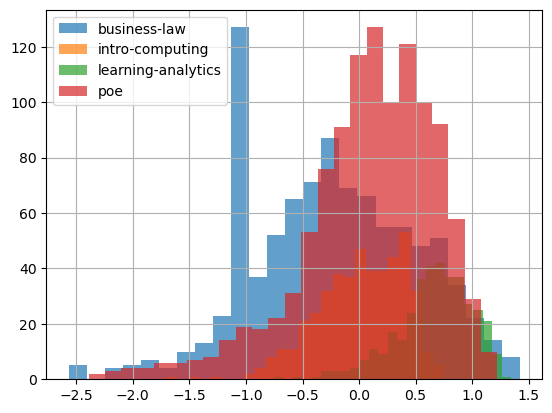

In [5]:
df["content_score"].groupby(level=0).hist(legend=True, bins=25, alpha=0.7);

## Simulating the Bayesian Score Distributions

If we had used a Bayesian approach to estimate the scoring distribution over time during these deployments...

In [6]:
mu_global = 0.8
k_global = 15
alpha_global = 4
beta_global = 3.5
k_volume = 15

mu_global = 0.8
k_global = 1
alpha_global = 4
beta_global = 1
k_volume = 15

In [7]:
volumes = {}
students = {}
volume_updates = defaultdict(list)
student_updates = defaultdict(list)
submission_threshold = []

start_threshold = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=0.25).threshold

for row in df.itertuples():
    volume_name = row.Index[0]
    if volume_name not in volumes:
        volumes[volume_name] = conjugate_normal(mu_global, k_global, alpha_global, beta_global, percentile=0.25)
    volume = volumes[volume_name]

    # Create student prior from volume prior information
    student_dist = conjugate_normal(volume.mu, k_volume, volume.alpha, volume.beta, percentile=0.25)

    # Update Volume Prior
    if volume.k > 10:
        volume.update([row.content_score], increment_k=False)
    else:
        volume.update([row.content_score], increment_k=True)
    volume_updates[volume_name].append((volume.mu, volume.sigma, volume.threshold))

    if row.user_id in students:
        score_history = students[row.user_id]
        student_dist.update(score_history)
    else:
        students[row.user_id] = []

    # Record threshold
    submission_threshold.append(student_dist.threshold)

    # Append score to history
    student_updates[row.user_id].append((student_dist.mu, student_dist.sigma, student_dist.threshold, row.content_score))
    students[row.user_id].append(row.content_score)

df["bayesian_threshold"] = submission_threshold
submission_threshold = pd.DataFrame({"threshold": submission_threshold}, index=df.id)

### Check how pass/fails differ with Bayesian updating

In [8]:
def get_percent(ser, name="Default"):
    display(ser.value_counts(normalize=True).rename(name).mul(100).round(1).astype(str) + '%')

print("All Summaries\n")
get_percent(df.content_score > 0)
print()
get_percent(df["content_score"] > submission_threshold.threshold.values, name="Bayes")

print("First Submissions\n")
first_submissions_w_thresholds = pd.merge(first_submissions, submission_threshold.threshold, left_on="id", right_on="id")
get_percent(first_submissions_w_thresholds["content_score"] > 0)
print()
get_percent(first_submissions_w_thresholds["content_score"] > first_submissions_w_thresholds.threshold, name="Bayes")

All Summaries



content_score
True     57.1%
False    42.9%
Name: Default, dtype: object

content_score
True     74.0%
False    26.0%
Name: Bayes, dtype: object

First Submissions



content_score
True     61.7%
False    38.3%
Name: Default, dtype: object

True     74.9%
False    25.1%
Name: Bayes, dtype: object

### By Volume

,Volume,20th Percentile,Bayesian Personalized,Bayesian Volume Prior Only
0,business-law,0.71,0.67,0.75
1,intro-computing,0.78,0.75,0.75
2,learning-analytics,0.77,0.76,0.77
3,poe,0.79,0.79,0.79


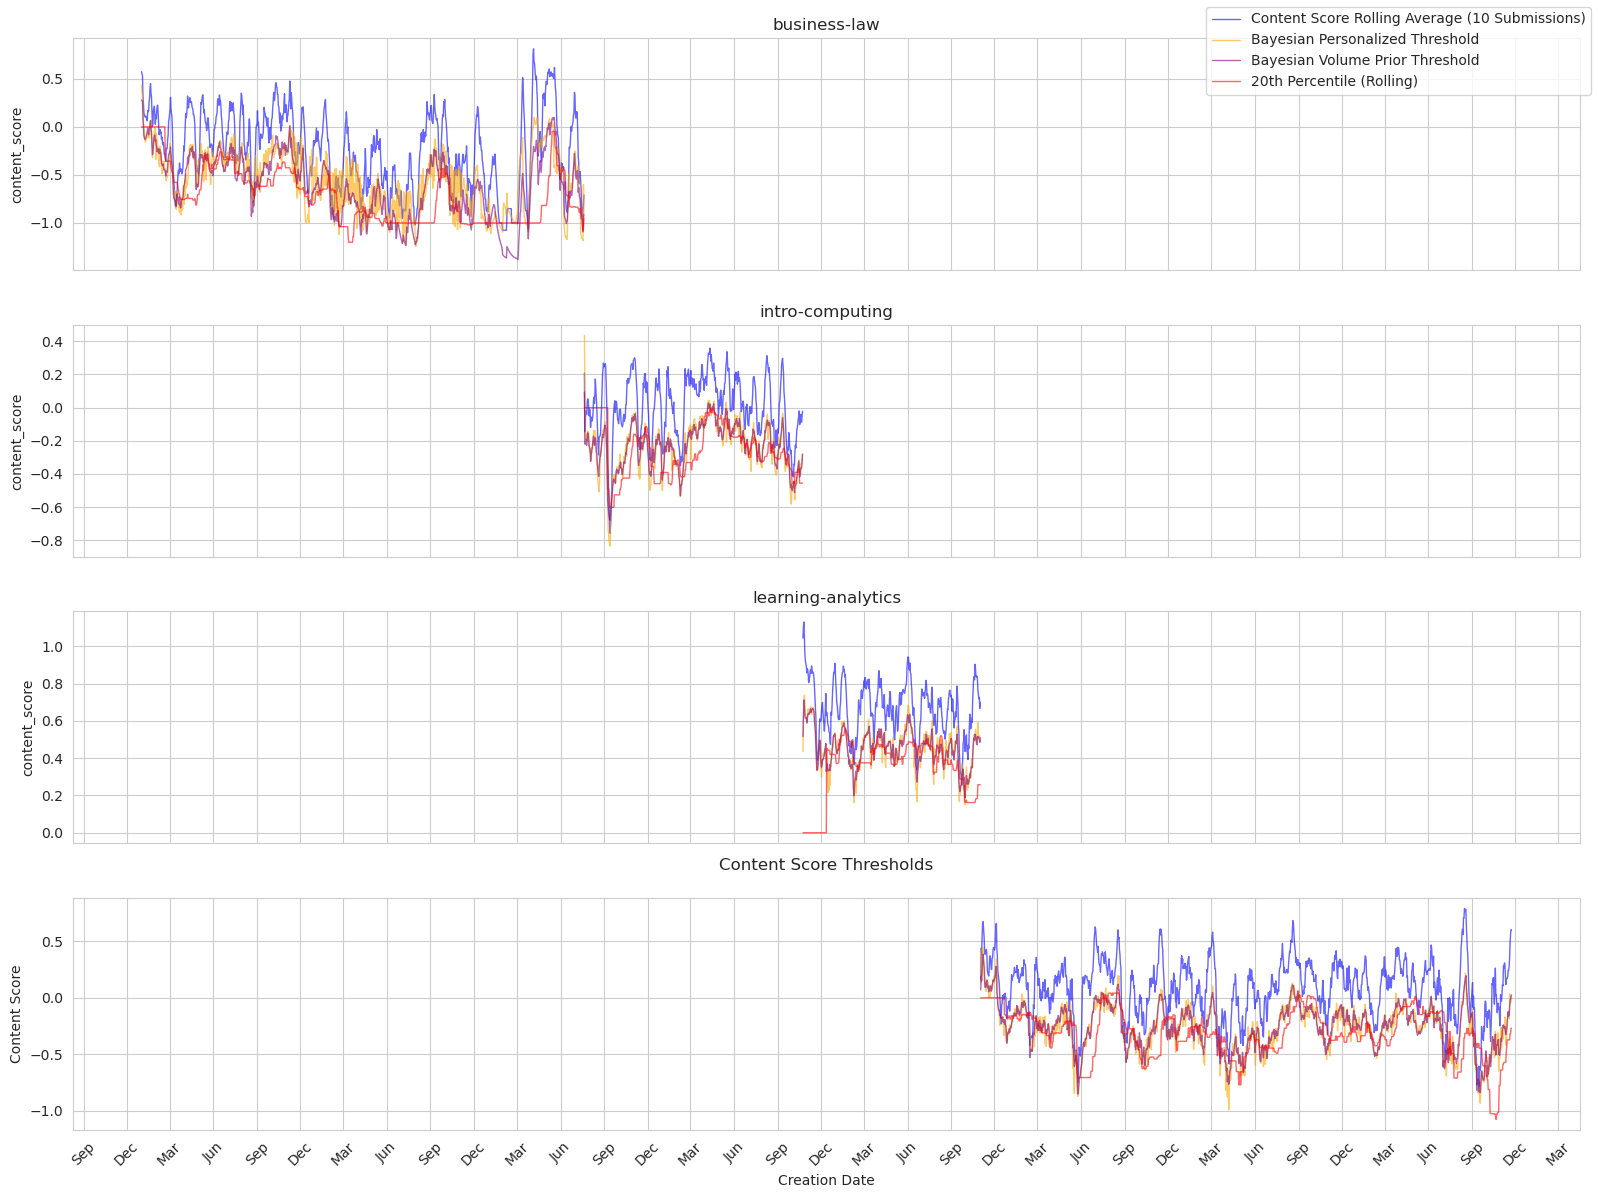

In [9]:
df = df.sort_values('created_at')

sns.set_style("whitegrid")
fig, axs = plt.subplots(4, figsize=(16, 12), sharex=True)

pass_rates = []

for ax, (name, group) in zip(axs, df.reset_index(0, names="volume").groupby("volume")):
    group = group.sort_values("created_at")

    # Create the main line plot
    # sns.scatterplot(data=df, x='created_at', y='content_score', 
    #              label='Raw Score', alpha=0.6, color='gray')
    
    # Calculate and plot rolling average (10 submissions)
    rolling_avg = group['content_score'].rolling(window=10, min_periods=1).mean()
    sns.lineplot(ax=ax, x=group["created_at"], y=rolling_avg, 
                 label='Content Score Rolling Average (10 Submissions)', legend=False,
                 color='blue', linewidth=1, alpha=0.6)
    
    # Draw Bayesian Threshold
    sns.lineplot(ax=ax, data=group, x='created_at', y='bayesian_threshold', 
                 label='Bayesian Personalized Threshold', legend=False,
                 color='orange', linewidth=1, alpha=0.6)

    # Draw Volume Prior
    updates_array = np.array(volume_updates[name])
    sns.lineplot(ax=ax, x=group['created_at'], y=updates_array[:,2], 
                 label='Bayesian Volume Prior Threshold', legend=False,
                 color='purple', linewidth=1, alpha=0.6)
    
    # Draw Observed 20th Percentile Threshold
    window_size = 50
    rolling_20th = group["content_score"].rolling(window=window_size, min_periods=1).quantile(0.2)


    # Skip first 100 scores for mean calculations
    group_subset = group.iloc[100:] if len(group) > 100 else group
    
    pass_rates.append({
        "Volume": name,
        "20th Percentile": (group["content_score"] > rolling_20th).astype(int).mean(),
        "Bayesian Personalized": (group["content_score"] > group["bayesian_threshold"]).astype(int).mean(),
        "Bayesian Volume Prior Only": (group["content_score"] > updates_array[:,2]).astype(int).mean(),
        # "20th Percentile (Skip 100)": (group_subset["content_score"] > rolling_20th[100:] if len(group) > 100 else rolling_20th).astype(int).mean(),
        # "Bayesian Personalized (Skip 100)": (group_subset["content_score"] > group_subset["bayesian_threshold"]).astype(int).mean(),
        # "Bayesian Volume Prior Only (Skip 100)": (group_subset["content_score"] > updates_array[100:,2] if len(group) > 100 else updates_array[:,2]).astype(int).mean()
    })

    # Manually set the threshold for the first window_size samples
    # Since we don't have enough data to calculate a fair rolling average
    rolling_20th.iloc[:window_size] = 0.0
    sns.lineplot(
        ax=ax, data=group, x='created_at', y=rolling_20th,
        label='20th Percentile (Rolling)', legend=False,
        color='red', linewidth=1, alpha=0.6
    )

    ax.title.set_text(name)
    
    # Format x-axis to show only month-year
    plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
    plt.gca().xaxis.set_major_locator(mpl.dates.MonthLocator(interval=3))
    
    # Rotate x-axis labels
    plt.xticks(rotation=45)

# Show Pass Rates
display(pd.DataFrame(pass_rates).round(2))

# Add legend
labels_handles = {}
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        labels_handles[label] = handle

fig.legend(labels_handles.values(), labels_handles.keys(), loc='upper right', bbox_transform=fig.transFigure, ncol=1)

plt.title('Content Score Thresholds', pad=20)
plt.xlabel('Creation Date')
plt.ylabel('Content Score')
plt.tight_layout()
    
plt.show();

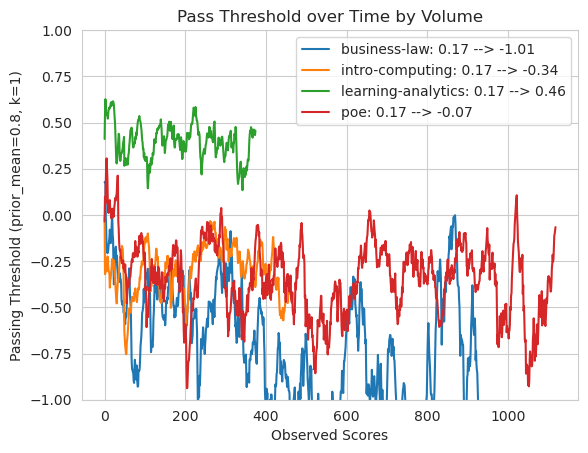

In [36]:
fig, ax = plt.subplots()
ax.set_ylim(-1, 1)

for volume_name, updates in volume_updates.items():
    arr = np.array(updates)
    means = arr[:,0]
    sigmas = arr[:,1]
    thresholds = arr[:,2]
    x = np.linspace(0, len(updates), len(updates))
    end_threshold = volumes[volume_name].threshold
    ax.plot(x, thresholds, label=f"{volume_name}: {start_threshold:.2f} --> {end_threshold:.2f}")    
    # ax.fill_between(x, means - sigmas, means + sigmas, alpha=0.05)
ax.set_title("Pass Threshold over Time by Volume")
ax.set_ylabel(f"Passing Threshold (prior_mean={mu_global}, k={k_global})")
ax.set_xlabel("Observed Scores")
ax.legend();